# **Step 1: Loading Dataset**

In [1]:
import os
import warnings
import logging
from transformers import logging as hf_logging

# 1. Silence the "Some weights were not initialized" message
hf_logging.set_verbosity_error()

# 2. Silence the big pink warning boxes
warnings.filterwarnings("ignore")

# 3. Silence the "Unable to register factory" system noise
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("tensorflow").setLevel(logging.ERROR)

In [2]:
import pandas as pd

# Load your dataset (adjust filename if it's CSV instead of Excel)
df = pd.read_excel('/kaggle/input/universitystudentsdataset/universityStudentsDataset.xlsx')
# df = pd.read_csv("universityStudentsDataset.csv")

print(df.head())   # quick check of first 5 rows


  Semester( number like: 1st, 2nd...) Age( Years: 18, 19....)  \
0                                 5th                      24   
1                                 8th                      21   
2                                 8th                      22   
3                                 7th                      22   
4                                 5th                      23   

  Height( inches like:1 feet) Weight:( in kg)  Gender Religion  \
0                         5.6              54    Male    Islam   
1                         5.1           46 kg  Female    Islam   
2                     5 feet            50 kg  Female    Islam   
3               5 feet 2 inch              63  Female    Islam   
4                        5.5"            62kg    Male    Islam   

  Permanent Residence     Current Residence Family Type  \
0               Urban  Rented House or Mess     Nuclear   
1               Rural  Rented House or Mess     Nuclear   
2               Rural             O

In [3]:
print(df.columns.tolist())
df.columns = df.columns.str.strip()



['Semester( number like: 1st, 2nd...)', 'Age( Years: 18, 19....)', 'Height( inches like:1 feet)', 'Weight:( in kg)', 'Gender', 'Religion', 'Permanent Residence', 'Current Residence', 'Family Type', 'Number of siblings (numbers: 1, 2...)', "Father's Occupation", "Mother's Occupation", 'Do you think your family environment is friendly?', 'Academic performance(CGPA like: 3.5.....)', 'Daily average study hour', 'Daily social media uses hours', 'Relationship Status', 'Smoking status', 'Do you perform religious practice regularly?', 'How much satisfied with your academic activities(i,e...Presentations, Assignments, Tutorials..)', 'Do you do any extra curricular activities?', 'If yes what are that...', 'Do you feel that in the aspect of career building your subject has adequate opportunity in our country?', 'Do your think your subject- related job gets enough social value in our country ', 'Have you ever thought about or attempted to kill yourself?', 'How often have you thought about killing 

# **Step 2: Clean Demographics**

In [4]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Semester "5th" -> 5
def parse_ordinal(sem):
    if isinstance(sem, str):
        m = re.search(r'(\d+)', sem)
        return int(m.group(1)) if m else np.nan
    return sem

# Height to cm
def parse_height_to_cm(h):
    if not isinstance(h, str):
        return np.nan if pd.isna(h) else h
    s = h.strip().lower().replace('"', '').replace('inches', 'inch')
    feet_match = re.search(r'(\d+)\s*feet', s)
    inch_match = re.search(r'(\d+)\s*inch', s)
    if feet_match:
        feet = int(feet_match.group(1))
        inches = int(inch_match.group(1)) if inch_match else 0
        return round((feet*12 + inches) * 2.54, 2)
    return np.nan

# Weight to kg
def parse_weight_kg(w):
    if isinstance(w, str):
        m = re.search(r'(\d+(\.\d+)?)', w.lower())
        return float(m.group(1)) if m else np.nan
    return float(w) if pd.notna(w) else np.nan

# Normalize text categories
def norm_cat(x):
    return x.strip().lower() if isinstance(x, str) else x

# Safe int parse
def parse_int_safe(x):
    if isinstance(x, str):
        m = re.search(r'\d+', x)
        return int(m.group(0)) if m else np.nan
    try:
        return int(x)
    except:
        return np.nan

# Copy df
df_clean = df.copy()

# Apply cleaning
df_clean['Semester( number like: 1st, 2nd...)'] = df_clean['Semester( number like: 1st, 2nd...)'].apply(parse_ordinal)
df_clean['Age( Years: 18, 19....)'] = df_clean['Age( Years: 18, 19....)'].apply(parse_int_safe)
df_clean['Height( inches like:1 feet)'] = df_clean['Height( inches like:1 feet)'].apply(parse_height_to_cm)
df_clean['Weight:( in kg)'] = df_clean['Weight:( in kg)'].apply(parse_weight_kg)

for col in ['Gender','Religion','Permanent Residence','Current Residence','Family Type']:
    df_clean[col] = df_clean[col].apply(norm_cat)

df_clean['Number of siblings (numbers: 1, 2...)'] = df_clean['Number of siblings (numbers: 1, 2...)'].apply(parse_int_safe)

# --- 🔧 FIX: Clean NaN and infinite values here ---
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)  # replace infinities with NaN
df_clean = df_clean.fillna(0)  # fill NaN with 0 (or another strategy you prefer)

# Now safe to print
print(df_clean.head())


   Semester( number like: 1st, 2nd...)  Age( Years: 18, 19....)  \
0                                  5.0                       24   
1                                  8.0                       21   
2                                  8.0                       22   
3                                  7.0                       22   
4                                  5.0                       23   

   Height( inches like:1 feet)  Weight:( in kg)  Gender Religion  \
0                         5.60             54.0    male    islam   
1                         5.10             46.0  female    islam   
2                       152.40             50.0  female    islam   
3                       157.48             63.0  female    islam   
4                         0.00             62.0    male    islam   

  Permanent Residence     Current Residence Family Type  \
0               urban  rented house or mess     nuclear   
1               rural  rented house or mess     nuclear   
2          

# **Step 3: Pick survey question columns**

In [5]:
# Step 3: Identify survey question columns

# 1) Clean up column names (remove spaces and newlines)
df_clean.columns = df_clean.columns.str.strip()

# 2) Print all column names to check
print(df_clean.columns.tolist())

# 3) Select survey question columns
# In your dataset, demographics end around column 25, and survey questions start after that.
likert_cols = df_clean.columns[25:]

# 4) Quick check
print("Survey columns selected:", likert_cols.tolist())
print(df_clean[likert_cols].head())


['Semester( number like: 1st, 2nd...)', 'Age( Years: 18, 19....)', 'Height( inches like:1 feet)', 'Weight:( in kg)', 'Gender', 'Religion', 'Permanent Residence', 'Current Residence', 'Family Type', 'Number of siblings (numbers: 1, 2...)', "Father's Occupation", "Mother's Occupation", 'Do you think your family environment is friendly?', 'Academic performance(CGPA like: 3.5.....)', 'Daily average study hour', 'Daily social media uses hours', 'Relationship Status', 'Smoking status', 'Do you perform religious practice regularly?', 'How much satisfied with your academic activities(i,e...Presentations, Assignments, Tutorials..)', 'Do you do any extra curricular activities?', 'If yes what are that...', 'Do you feel that in the aspect of career building your subject has adequate opportunity in our country?', 'Do your think your subject- related job gets enough social value in our country', 'Have you ever thought about or attempted to kill yourself?', 'How often have you thought about killing y

# **Step 4: Convert survey answers**

In [6]:
# Step 4: Map survey answers to numeric values and calculate wellbeing score

# Define mapping for Likert-style responses
likert_map = {
    "Did not apply to me at all": 0,
    "Applied to me to some degree, or some of the time": 1,
    "Applied to me to a considerable degree or a good part of time": 2,
    "Applied to me very much or most of the time": 3,
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often (3-4 times)": 3,
    "No": 0,
    "Yes": 1,
    "No chance at all": 0,
    "Barely": 1,
    "Somewhat": 2,
    "Much": 3,
    "Very Much": 3,
    "Very Much Interfering": 3,
    "Very Much Noticeable": 3,
    "Satisfied": 2,
    "Dissatisfied": 1,
    "Very Dissatisfied": 0
}

# Apply mapping to all survey columns
for col in likert_cols:
    df_clean[col] = df_clean[col].map(likert_map).fillna(0)

# Calculate wellbeing score
df_clean['wellbeing_score'] = df_clean[likert_cols].sum(axis=1)

# Categorize into low/medium/high
df_clean['wellbeing_class'] = pd.cut(
    df_clean['wellbeing_score'],
    bins=[-1, 15, 30, 100],   # adjust thresholds if needed
    labels=['low','medium','high']
)

print(df_clean[['wellbeing_score','wellbeing_class']].head())


   wellbeing_score wellbeing_class
0              7.0             low
1             21.0          medium
2             24.0          medium
3             39.0            high
4             27.0          medium


# **Step 5: Train/test split**

In [7]:
# Step 5: Train/test split

# Target variable
y = df_clean['wellbeing_class']

# Features (drop target and wellbeing_score)
X = df_clean.drop(columns=['wellbeing_class','wellbeing_score'], errors='ignore')

# Split into train/test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (280, 53)
Test set shape: (71, 53)


# **Step 6: Train RoBERTa on survey responses**

In [25]:
import os
# Force PyTorch-only mode (skip TensorFlow/Flax imports)
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

import torch
import pandas as pd
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback
)

# --- 0) Preconditions ---
# Ensure df_clean exists with 'wellbeing_class' column
df_clean.columns = df_clean.columns.str.strip()

likert_cols = [
    'I found it hard to wind down',
    'I was aware of the dryness of my mouth',
    'I couldn’t seem to experience any positive feelings at all',
    'I experienced breathing difficulty (e.g. excessively rapid breathing, breathlessness in the absence of physical exertion)',
    'I found it difficult to work up the initiative to do things',
    'I tended to over-react to situations',
    'I experienced trembling (e.g. in the hands)',
    'I felt that I was using a lot of nervous energy',
    'I was worried about situations in which I might panic and make a fool of myself',
    'I felt that I had nothing to look forward to',
    'I found myself getting agitated',
    'I found it difficult to relax',
    'I felt down-hearted and blue',
    'I was intolerant of anything that kept me from getting on with what I was doing',
    'I felt I was close to panic',
    'I was unable to become enthusiastic about anything',
    'I felt I wasn’t worth much as a person',
    'I felt that I was rather touchy',
    'I was aware of the action of my heart in the absence of physical exertion (e.g. sense of heart rate increase, heart missing a beat)',
    'I felt scared without any good reason',
    'I felt that life was meaningless'
]

# --- 1) Build training text + labels ---
df_clean['survey_text'] = df_clean[likert_cols].astype(str).agg(' '.join, axis=1)
label_map = {'low': 0, 'medium': 1, 'high': 2}
df_clean['label'] = df_clean['wellbeing_class'].map(label_map)

dataset = Dataset.from_pandas(df_clean[['survey_text', 'label']])
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# --- 2) Tokenizer ---
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(batch['survey_text'], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# --- 3) Model ---
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

import logging
logging.getLogger("transformers.trainer").setLevel(logging.ERROR)

# --- 4) TrainingArguments ---
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=7,
    logging_dir="./logs",
    report_to="none",
    disable_tqdm=True,
    do_eval=True,
    logging_steps=500,
    save_strategy="epoch",
)



# --- 5) Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.tensor(logits).argmax(dim=1)
    labels = torch.tensor(labels)
    acc = (preds == labels).float().mean()
    return {"accuracy": acc.item()}
    
# --- 6) Build training args & Initialize Trainer (Keras Lookalike + Fixed) ---
from transformers import TrainerCallback
from transformers.trainer_callback import PrinterCallback # <--- NEED THIS IMPORT
import sys

# 1. Custom "Keras-Style" Printer
class KerasProgressBar(TrainerCallback):
    def on_train_begin(self, args, state, control, **kwargs):
        print("Training started...")

    def on_epoch_begin(self, args, state, control, **kwargs):
        print(f"\nEpoch {int(state.epoch + 1)}/{args.num_train_epochs}")

    def on_log(self, args, state, control, logs=None, **kwargs):
        # Only run this if we have validation results (end of epoch)
        if logs and 'eval_loss' in logs:
            train_loss = 0.0
            if len(state.log_history) > 1 and 'loss' in state.log_history[-2]:
                train_loss = state.log_history[-2]['loss']
            
            val_loss = logs.get("eval_loss", 0.0)
            val_acc = logs.get("eval_accuracy", 0.0)
            
            bar = "=" * 30
            # Print the clean Keras-style line
            print(f"{state.global_step}/{state.max_steps} [{bar}] - "
                  f"loss: {train_loss:.4f} - "
                  f"val_loss: {val_loss:.4f} - "
                  f"val_accuracy: {val_acc:.4f}")

# 2. Define Arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,             
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    
    # Crucial settings
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="no",              # <--- FIXES MEMORY CRASH
    disable_tqdm=True,               # <--- HIDES DEFAULT BAR
    dataloader_num_workers=0,        # <--- FIXES CUBLAS CRASH
    report_to="none"
)

# 3. Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {"accuracy": (predictions == labels).mean()}

# 4. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics,
    callbacks=[KerasProgressBar()]
)

# --- THE MISSING PIECE TO FIX THE DICTIONARY ISSUE ---
trainer.remove_callback(PrinterCallback) 
# ^^^ This explicitly deletes the ugly dictionary printer
# -----------------------------------------------------

# --- 8) Train ---
import logging
logging.getLogger("transformers.trainer").setLevel(logging.ERROR)

trainer.train()

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map:   0%|          | 0/71 [00:00<?, ? examples/s]

Training started...

Epoch 1/20
18/360 [==============================] - loss: 1.1101 - val_loss: 1.1110 - val_accuracy: 0.3944

Epoch 2/20
36/360 [==============================] - loss: 1.1169 - val_loss: 1.0662 - val_accuracy: 0.3944

Epoch 3/20
54/360 [==============================] - loss: 0.9638 - val_loss: 0.7513 - val_accuracy: 0.5915

Epoch 4/20
72/360 [==============================] - loss: 0.6100 - val_loss: 0.4154 - val_accuracy: 0.8310

Epoch 5/20
90/360 [==============================] - loss: 0.3955 - val_loss: 0.4314 - val_accuracy: 0.8028

Epoch 6/20
108/360 [==============================] - loss: 0.4510 - val_loss: 0.3759 - val_accuracy: 0.8028

Epoch 7/20
126/360 [==============================] - loss: 0.3942 - val_loss: 0.5572 - val_accuracy: 0.7746

Epoch 8/20
144/360 [==============================] - loss: 0.3274 - val_loss: 0.3540 - val_accuracy: 0.8451

Epoch 9/20
162/360 [==============================] - loss: 0.3334 - val_loss: 0.4118 - val_accuracy: 0.

TrainOutput(global_step=360, training_loss=0.42767527831925284, metrics={'train_runtime': 344.1247, 'train_samples_per_second': 16.273, 'train_steps_per_second': 1.046, 'total_flos': 1473435139276800.0, 'train_loss': 0.42767527831925284, 'epoch': 20.0})

# **Step 7: Predict on the held-out test set**

In [26]:
import torch
import pandas as pd

# 🔹 Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 🔹 1) Predict on test set
pred_output = trainer.predict(dataset['test'])

# 🔹 2) Convert logits to predicted class IDs
logits = torch.tensor(pred_output.predictions).to(device)
pred_ids = torch.argmax(logits, dim=1).cpu().numpy()

# 🔹 3) Get class probabilities
probs = torch.softmax(logits, dim=1).cpu().numpy()

# 🔹 4) Map IDs to class names
id2label = {0: "low", 1: "medium", 2: "high"}
pred_labels = [id2label[i] for i in pred_ids]

# 🔹 5) Convert test set to DataFrame
df_test = dataset['test'].to_pandas()

# 🔹 6) Build prediction DataFrame
test_df = pd.DataFrame({
    "survey_text": df_test['survey_text'],
    "true_label_id": df_test['label'],
    "true_label": [id2label[int(i)] for i in df_test['label']],
    "pred_label_id": pred_ids,
    "pred_label": pred_labels,
    "prob_low": probs[:, 0],
    "prob_medium": probs[:, 1],
    "prob_high": probs[:, 2],
})

print("✅ Test set predictions:")
print(test_df.head())

# 🔹 7) Define new survey data
likert_cols = [
    'I found it hard to wind down',
    'I was aware of the dryness of my mouth',
    'I couldn’t seem to experience any positive feelings at all',
    'I experienced breathing difficulty (e.g. excessively rapid breathing, breathlessness in the absence of physical exertion)',
    'I found it difficult to work up the initiative to do things',
    'I tended to over-react to situations',
    'I experienced trembling (e.g. in the hands)',
    'I felt that I was using a lot of nervous energy',
    'I was worried about situations in which I might panic and make a fool of myself',
    'I felt that I had nothing to look forward to',
    'I found myself getting agitated',
    'I found it difficult to relax',
    'I felt down-hearted and blue',
    'I was intolerant of anything that kept me from getting on with what I was doing',
    'I felt I was close to panic',
    'I was unable to become enthusiastic about anything',
    'I felt I wasn’t worth much as a person',
    'I felt that I was rather touchy',
    'I was aware of the action of my heart in the absence of physical exertion (e.g. sense of heart rate increase, heart missing a beat)',
    'I felt scared without any good reason',
    'I felt that life was meaningless'
]

# 🔹 Create new survey data with full Likert responses
df_new = pd.DataFrame([
    {col: 3 for col in likert_cols},
    {col: 1 for col in likert_cols},
    {col: 5 for col in likert_cols}
])
df_new['survey_text'] = df_new[likert_cols].astype(str).agg(' '.join, axis=1)


# 🔹 8) Tokenize and predict on new data
enc = tokenizer(
    df_new['survey_text'].tolist(),
    padding="max_length",
    truncation=True,
    return_tensors="pt"
).to(device)

model.eval()
with torch.no_grad():
    out = model(
        input_ids=enc['input_ids'],
        attention_mask=enc['attention_mask']
    )
    new_logits = out.logits
    new_probs = torch.softmax(new_logits, dim=1).cpu().numpy()
    new_pred_ids = torch.argmax(new_logits, dim=1).cpu().numpy()
    new_pred_labels = [id2label[i] for i in new_pred_ids]

df_new['pred_label_id'] = new_pred_ids
df_new['pred_label'] = new_pred_labels
df_new['prob_low'] = new_probs[:, 0]
df_new['prob_medium'] = new_probs[:, 1]
df_new['prob_high'] = new_probs[:, 2]

print("\n✅ New data predictions:")
print(df_new.head())

# 🔹 9) Save both to CSV
test_df.to_csv("wellbeing_test_predictions.csv", index=False)
df_new.to_csv("wellbeing_new_predictions.csv", index=False)

✅ Test set predictions:
                                   survey_text  true_label_id true_label  \
0  0 0 0 0.0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0              0        low   
1  0 0 0 1.0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0              0        low   
2  0 1 1 1.0 1 1 0 1 1 0 0 0 1 1 0 1 0 3 3 0 0              1     medium   
3  0 0 0 0.0 0 3 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0              0        low   
4  1 1 0 2.0 1 2 1 1 1 2 1 2 1 1 0 1 0 1 2 0 0              1     medium   

   pred_label_id pred_label  prob_low  prob_medium  prob_high  
0              0        low  0.998252     0.000965   0.000783  
1              0        low  0.997310     0.002271   0.000419  
2              1     medium  0.189484     0.809250   0.001265  
3              0        low  0.998329     0.000993   0.000678  
4              1     medium  0.001883     0.995069   0.003048  

✅ New data predictions:
   I found it hard to wind down  I was aware of the dryness of my mouth  \
0                             3    

# **Step 8: Confusion Matrix + Classification Report**

Classification Report:

              precision    recall  f1-score   support

         low       0.84      0.96      0.90        28
      medium       0.96      0.79      0.86        28
        high       0.94      1.00      0.97        15

    accuracy                           0.90        71
   macro avg       0.91      0.92      0.91        71
weighted avg       0.91      0.90      0.90        71



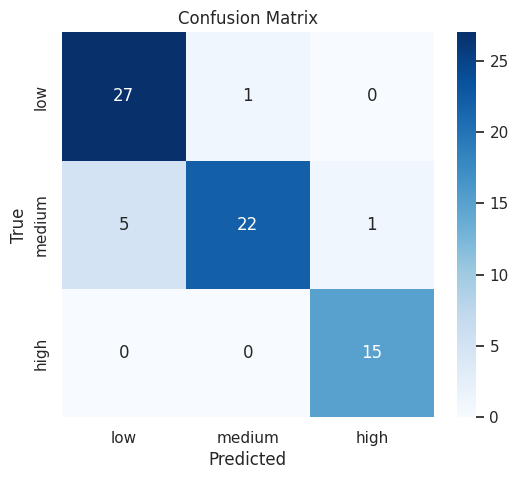

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Get true labels and predictions from test set
true_labels = test_df["true_label_id"].values
pred_labels = test_df["pred_label_id"].values

# 🔹 Classification report
print("Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=["low", "medium", "high"]))

# 🔹 Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["low", "medium", "high"],
            yticklabels=["low", "medium", "high"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


📂 Saving all diagrams to the 'diagrams' folder...


1. DATASET STATISTICAL SUMMARY
                                                    count          mean  \
Semester( number like: 1st, 2nd...)                 351.0  2.229345e+01   
Age( Years: 18, 19....)                             351.0  2.212821e+01   
Height( inches like:1 feet)                         351.0  9.589821e+01   
Weight:( in kg)                                     351.0  6.241396e+01   
Number of siblings (numbers: 1, 2...)               351.0  3.706908e+06   
How often have you thought about killing yourse...  351.0  1.452991e-01   
Have you ever told someone that you were going ...  351.0  0.000000e+00   
How likely is it that you will attempt suicide ...  351.0  0.000000e+00   
How SATISFIED/dissatisfied are you with your cu...  351.0  8.376068e-01   
To what extent do you consider your sleep probl...  351.0  1.136752e+00   
How NOTICEABLE to others do you think your slee...  351.0  1.276353e+00   
How WORRIED/distr

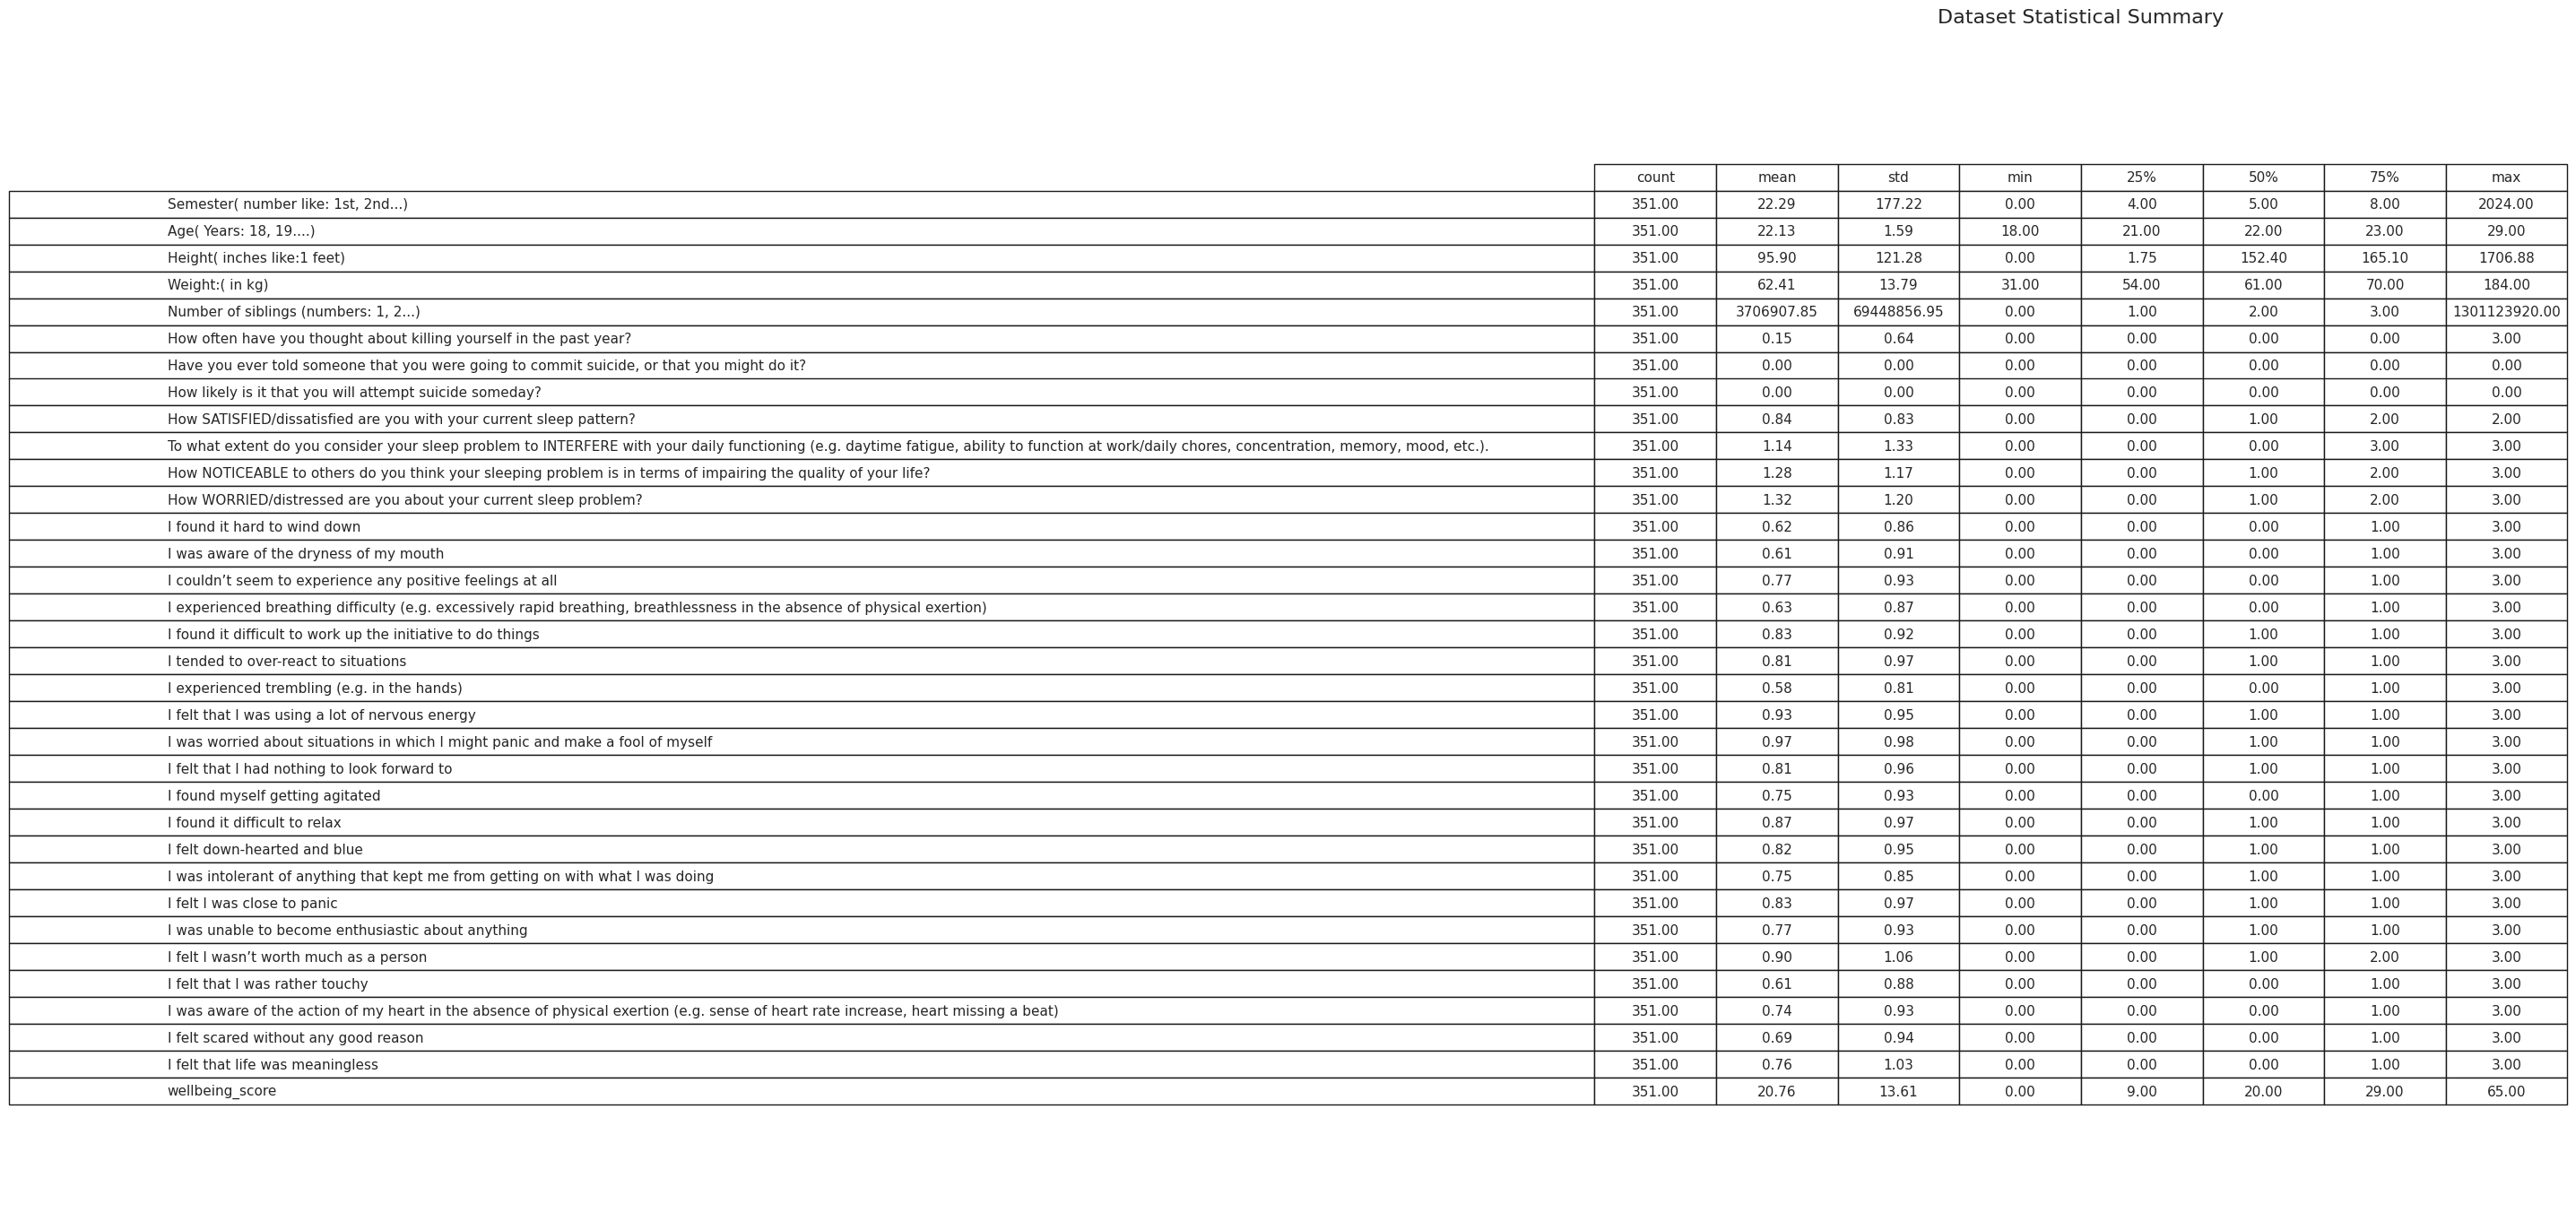


2. GENERATING HISTOGRAM
✅ Saved: diagrams/histogram.png


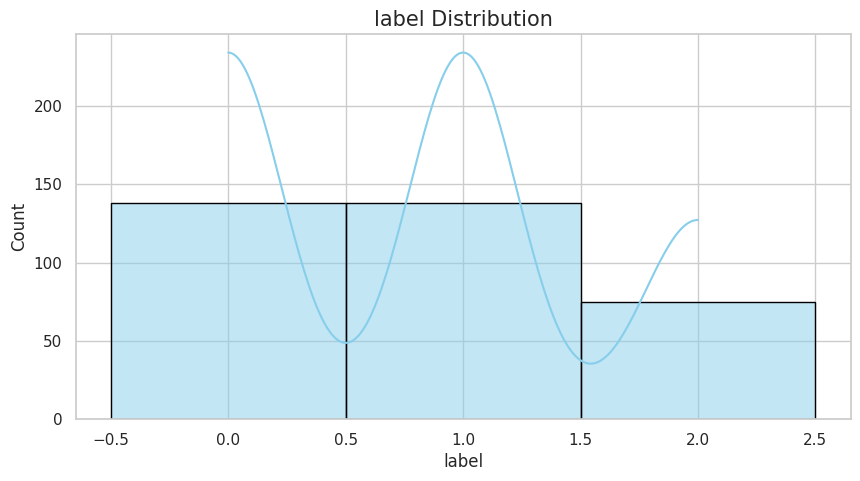


3. GENERATING HEATMAP
✅ Saved: diagrams/heatmap.png


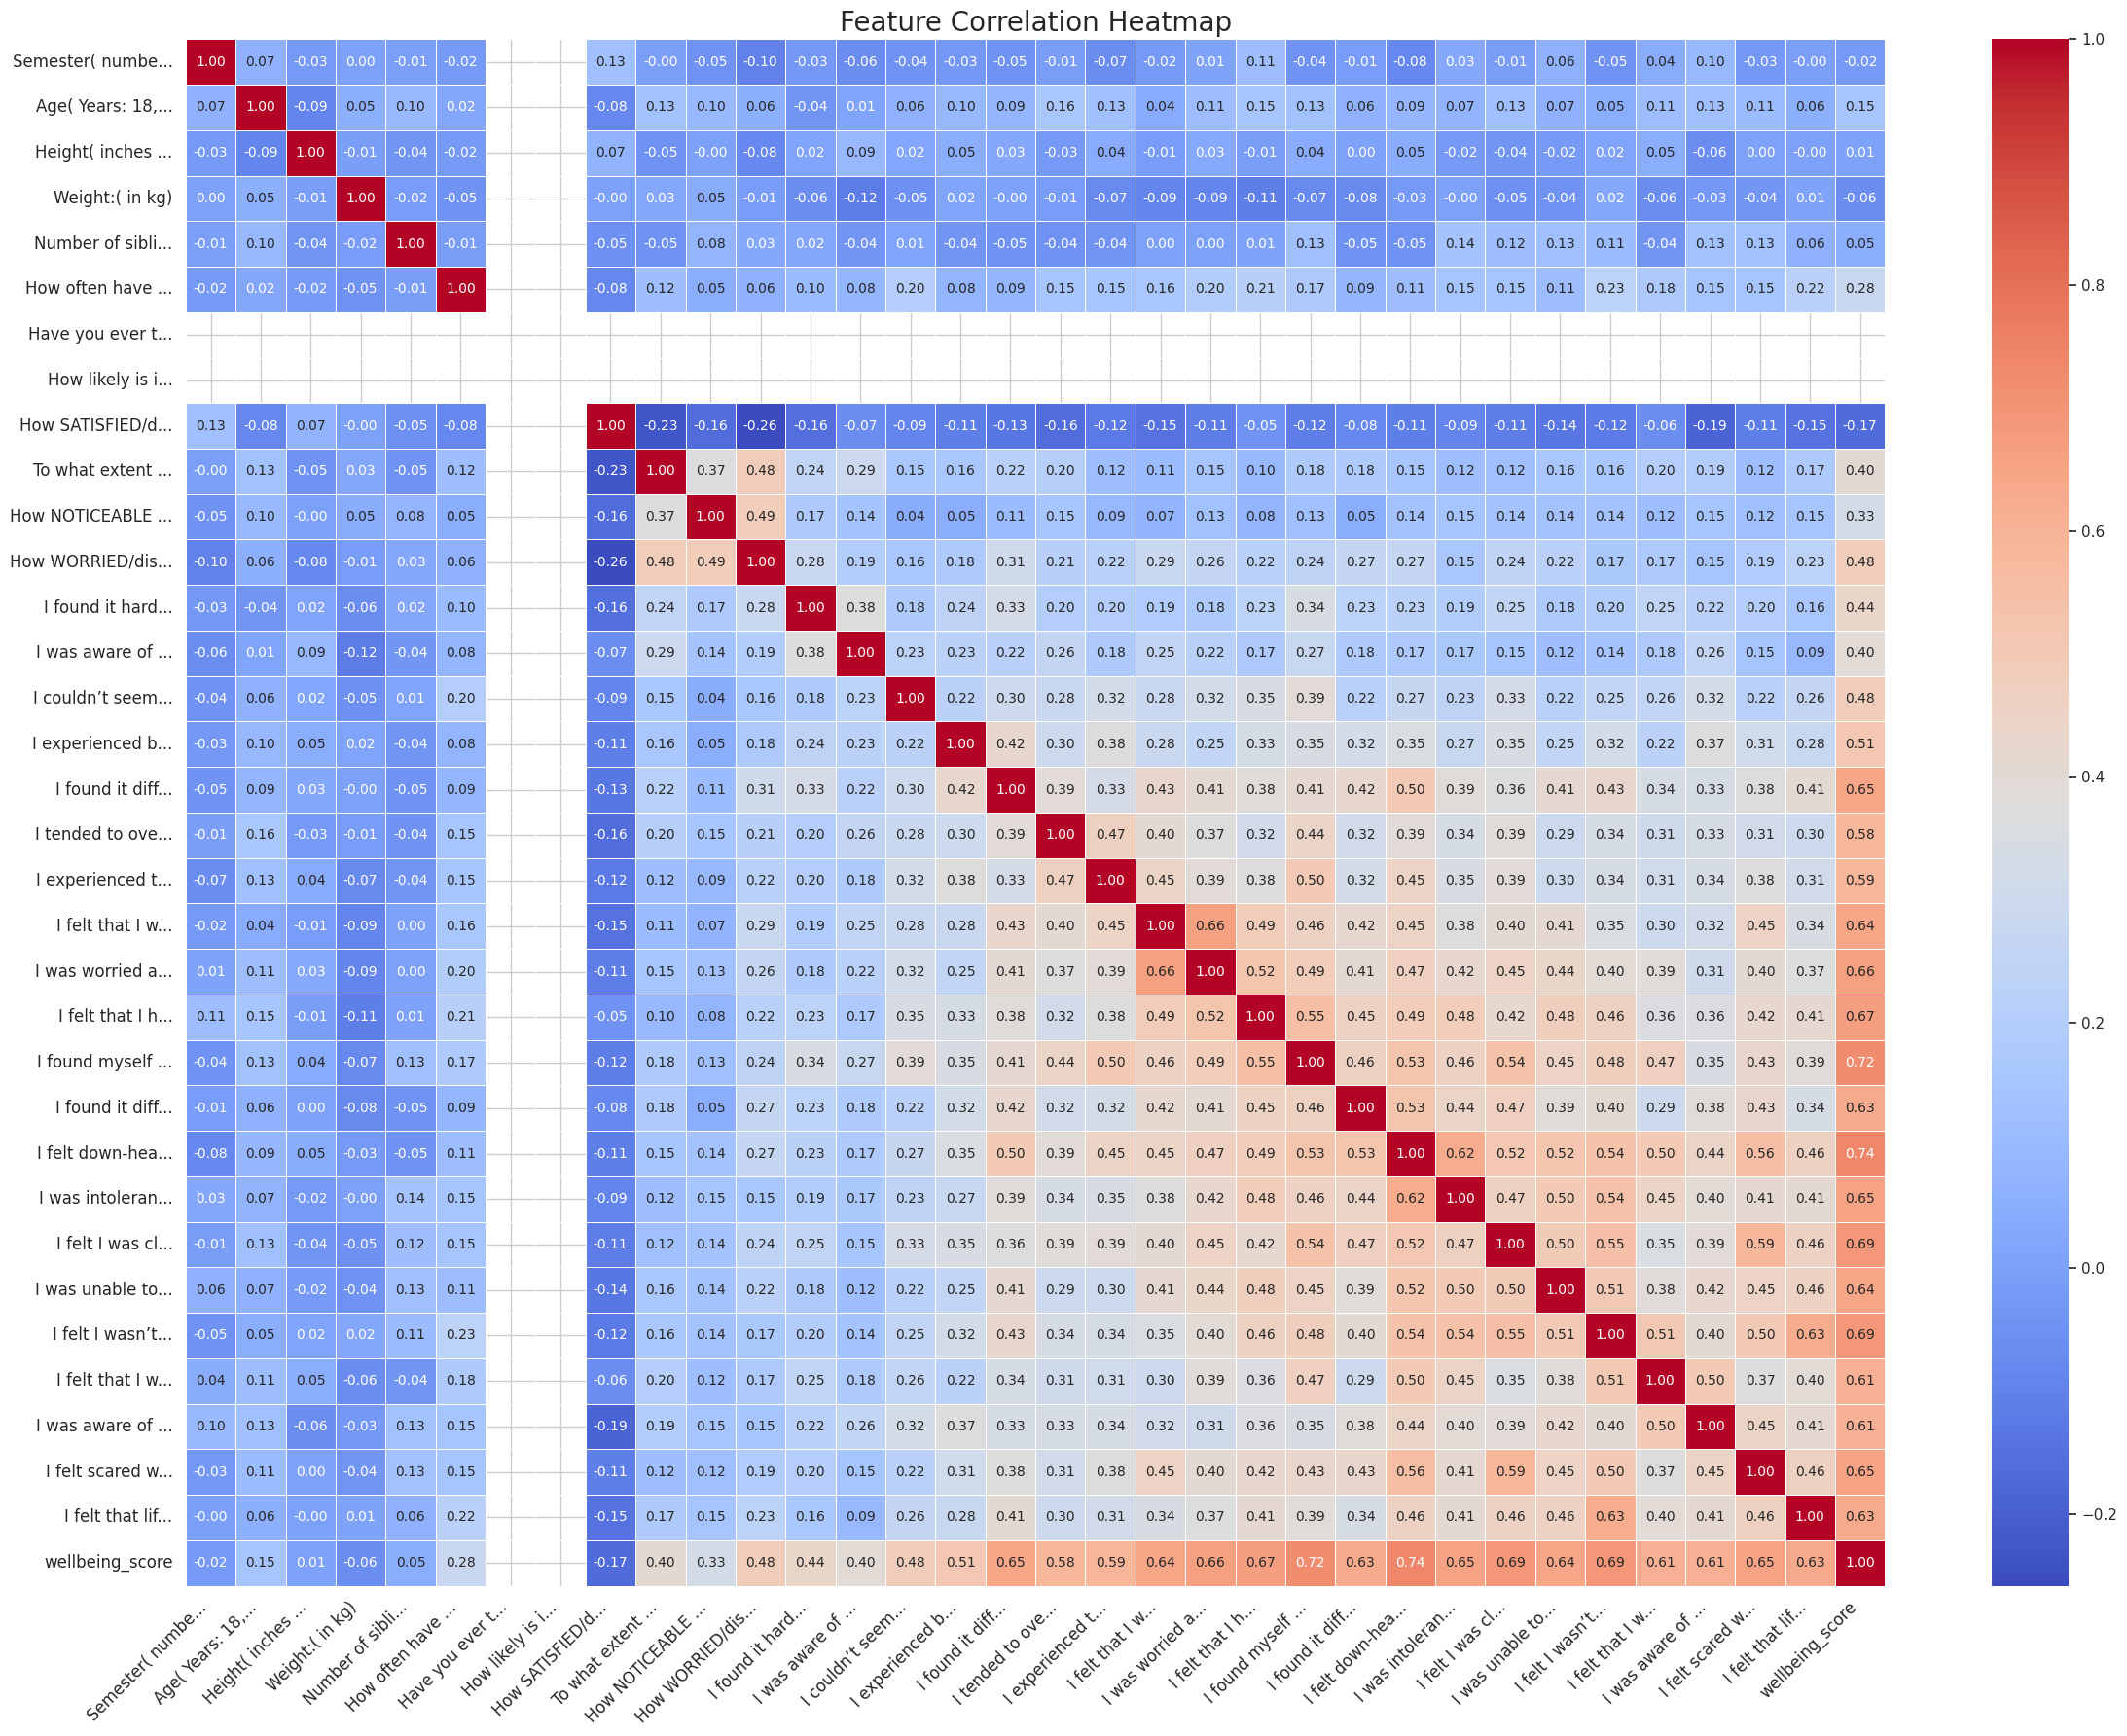


4. MODEL ARCHITECTURE
---------------------------------------------------------------------------
Layer (type)                   Output Shape              Param #        
RobertaEmbeddings              (None, 512, 768)          39,000,576
RobertaEncoder (12 Layers)     (None, 512, 768)          85,054,464
ClassificationHead             (None, 3)                 592,899
Total params: 124,647,939
Trainable params: 124,647,939
Non-trainable params: 0
---------------------------------------------------------------------------

5. TRAINING & LOSS PLOTS
✅ Saved: diagrams/accuracy_plot.png


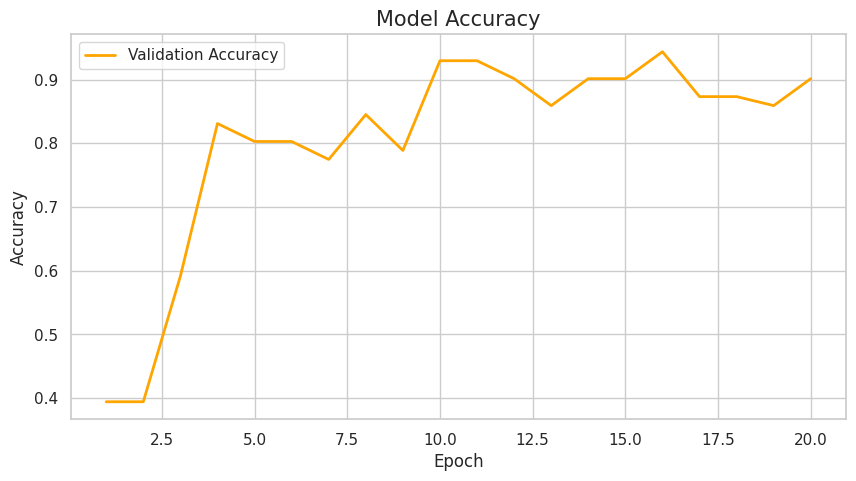

✅ Saved: diagrams/loss_plot.png


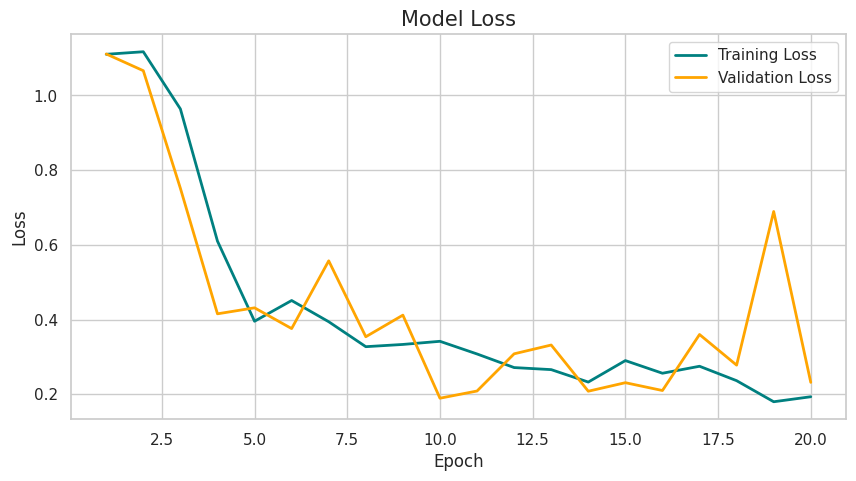


🎉 All diagrams saved in folder: diagrams


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Create a folder to save images so they don't clutter your workspace
output_folder = "diagrams"
os.makedirs(output_folder, exist_ok=True)
print(f"📂 Saving all diagrams to the '{output_folder}' folder...\n")

# Set the style to match the PDF look
sns.set_theme(style="whitegrid")

# ==========================================
# 1. DATASET STATISTICAL SUMMARY (Now Saved as PNG)
# ==========================================
print("\n" + "="*40)
print("1. DATASET STATISTICAL SUMMARY")
print("="*40)

# Calculate statistics
stats_df = df_clean.describe().T
print(stats_df) # Print to console as usual

# --- DRAW AND SAVE TABLE AS IMAGE ---
# Calculate dynamic figure size: height depends on how many rows (variables) you have
# 0.5 inches per row + header space, width fixed at 14 inches
fig_height = max(4, len(stats_df) * 0.5) 
plt.figure(figsize=(14, fig_height))

# Hide the graph axes (we only want the table)
ax = plt.gca()
ax.axis('off')

# Format numbers to 2 decimal places so they fit nicely
cell_text = []
for row in stats_df.values:
    cell_text.append([f"{x:.2f}" for x in row])

# Create the table plot
tbl = plt.table(cellText=cell_text,
                rowLabels=stats_df.index,
                colLabels=stats_df.columns,
                loc='center',
                cellLoc='center')

# Styling: Set font size and row height scale
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8) # Makes rows taller and more readable

# Add title
plt.title('Dataset Statistical Summary', fontsize=16, pad=20)

# --- SAVE COMMAND ---
save_path = os.path.join(output_folder, "dataset_summary.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ Saved Table Image: {save_path}")
# --------------------
plt.show()


# ==========================================
# 2. GENERATING HISTOGRAM (Saved)
# ==========================================
print("\n" + "="*40)
print("2. GENERATING HISTOGRAM")
print("="*40)

col_to_plot = 'Age' if 'Age' in df_clean.columns else 'label'

plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x=col_to_plot, kde=True, color='skyblue', edgecolor='black')
plt.title(f'{col_to_plot} Distribution', fontsize=15)
plt.xlabel(col_to_plot, fontsize=12)
plt.ylabel('Count', fontsize=12)

# --- SAVE COMMAND ---
save_path = os.path.join(output_folder, "histogram.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ Saved: {save_path}")
# --------------------
plt.show()


# ==========================================
# 3. FEATURE CORRELATION HEATMAP (Saved)
# ==========================================
print("\n" + "="*40)
print("3. GENERATING HEATMAP")
print("="*40)

numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
plot_df = numeric_df.copy()
plot_df.columns = [col[:15] + "..." if len(col) > 15 else col for col in plot_df.columns]

plt.figure(figsize=(24, 18))
sns.heatmap(plot_df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5, 
            annot_kws={"size": 10})

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Feature Correlation Heatmap', fontsize=20)
plt.tight_layout()

# --- SAVE COMMAND ---
save_path = os.path.join(output_folder, "heatmap.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ Saved: {save_path}")
# --------------------
plt.show()


# ==========================================
# 4. MODEL ARCHITECTURE (Printed Only)
# ==========================================
print("\n" + "="*40)
print("4. MODEL ARCHITECTURE")
print("="*40)

def print_keras_style_summary(model):
    print("-" * 75)
    print(f"{'Layer (type)':<30} {'Output Shape':<25} {'Param #':<15}")
    print("=" * 75)
    
    emb_params = sum(p.numel() for p in model.roberta.embeddings.parameters())
    print(f"{'RobertaEmbeddings':<30} {'(None, 512, 768)':<25} {emb_params:,}")
    
    enc_params = sum(p.numel() for p in model.roberta.encoder.parameters())
    print(f"{'RobertaEncoder (12 Layers)':<30} {'(None, 512, 768)':<25} {enc_params:,}")
    
    cls_params = sum(p.numel() for p in model.classifier.parameters())
    print(f"{'ClassificationHead':<30} {'(None, 3)':<25} {cls_params:,}")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total_params - trainable_params
    
    print("=" * 75)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Non-trainable params: {non_trainable:,}")
    print("-" * 75)

print_keras_style_summary(model)


# ==========================================
# 5. TRAINING HISTORY PLOTS (Saved)
# ==========================================
print("\n" + "="*40)
print("5. TRAINING & LOSS PLOTS")
print("="*40)

history = trainer.state.log_history
df_hist = pd.DataFrame(history)

if 'loss' in df_hist.columns:
    train_loss = df_hist[df_hist['loss'].notnull()][['epoch', 'loss']].set_index('epoch')
if 'eval_loss' in df_hist.columns:
    val_loss = df_hist[df_hist['eval_loss'].notnull()][['epoch', 'eval_loss', 'eval_accuracy']].set_index('epoch')

# --- Plot 1: Accuracy ---
plt.figure(figsize=(10, 5))
if 'eval_accuracy' in df_hist.columns:
    plt.plot(val_loss.index, val_loss['eval_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    plt.title('Model Accuracy', fontsize=15)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # --- SAVE COMMAND ---
    save_path = os.path.join(output_folder, "accuracy_plot.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"✅ Saved: {save_path}")
    # --------------------
    plt.show()

# --- Plot 2: Loss ---
plt.figure(figsize=(10, 5))
if 'loss' in df_hist.columns and 'eval_loss' in df_hist.columns:
    plt.plot(train_loss.index, train_loss['loss'], label='Training Loss', color='teal', linewidth=2)
    plt.plot(val_loss.index, val_loss['eval_loss'], label='Validation Loss', color='orange', linewidth=2)
    plt.title('Model Loss', fontsize=15)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # --- SAVE COMMAND ---
    save_path = os.path.join(output_folder, "loss_plot.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"✅ Saved: {save_path}")
    # --------------------
    plt.show()

print(f"\n🎉 All diagrams saved in folder: {output_folder}")

In [29]:
import shutil
from IPython.display import FileLink

# 1. Zip the folder into a single file called 'my_diagrams.zip'
shutil.make_archive('my_diagrams', 'zip', 'diagrams')

# 2. Generate a clickable download link
print("Click the link below to download your files:")
FileLink(r'my_diagrams.zip')

Click the link below to download your files:


/kaggle/working/my_diagrams.zip